In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2, ResNet50V2
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2

In [13]:
# Variables
ROOT_DIR = "/media/DATA/.kaggle/autism-spectrum"
EPOCHS = 50
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)
ROTATION_DEGREE = 20

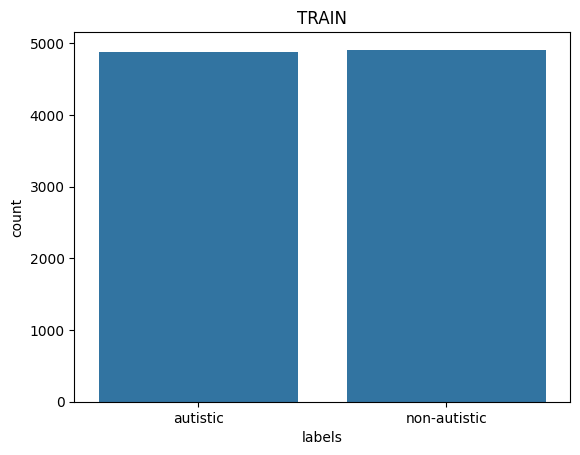

Train labels: 
labels
non-autistic    4912
autistic        4884
Name: count, dtype: int64


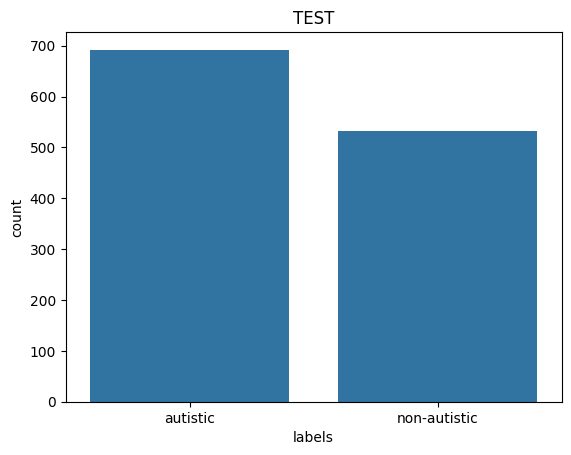

Test labels: 
labels
autistic        692
non-autistic    532
Name: count, dtype: int64


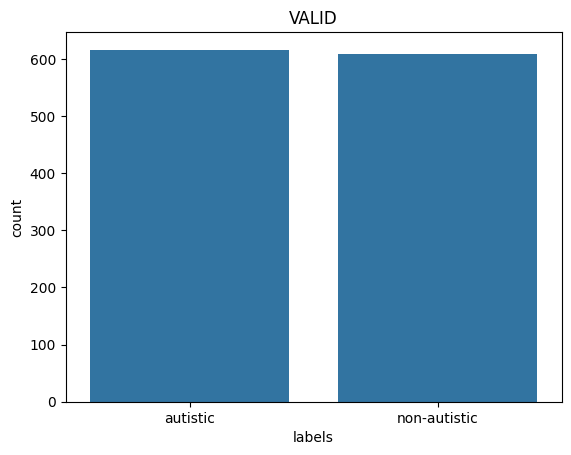

Valid labels: 
labels
autistic        616
non-autistic    608
Name: count, dtype: int64


In [14]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_train_80.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_test_10.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_valid_10.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
print(f"Train labels: ")
print(f"{train_df['labels'].value_counts()}")

sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
print(f"Test labels: ")
print(f"{test_df['labels'].value_counts()}")

sns.countplot(x='labels',data=valid_df)
plt.title('VALID')
plt.show()
print(f"Valid labels: ")
print(f"{valid_df['labels'].value_counts()}")

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=True
)

Found 9796 validated image filenames belonging to 2 classes.


In [16]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,       # Randomly rotates images by up to 20 degrees
    horizontal_flip=True,    # Flips images horizontally
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

Found 1224 validated image filenames belonging to 2 classes.


In [17]:
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuflle=True
)

Found 1224 validated image filenames belonging to 2 classes.


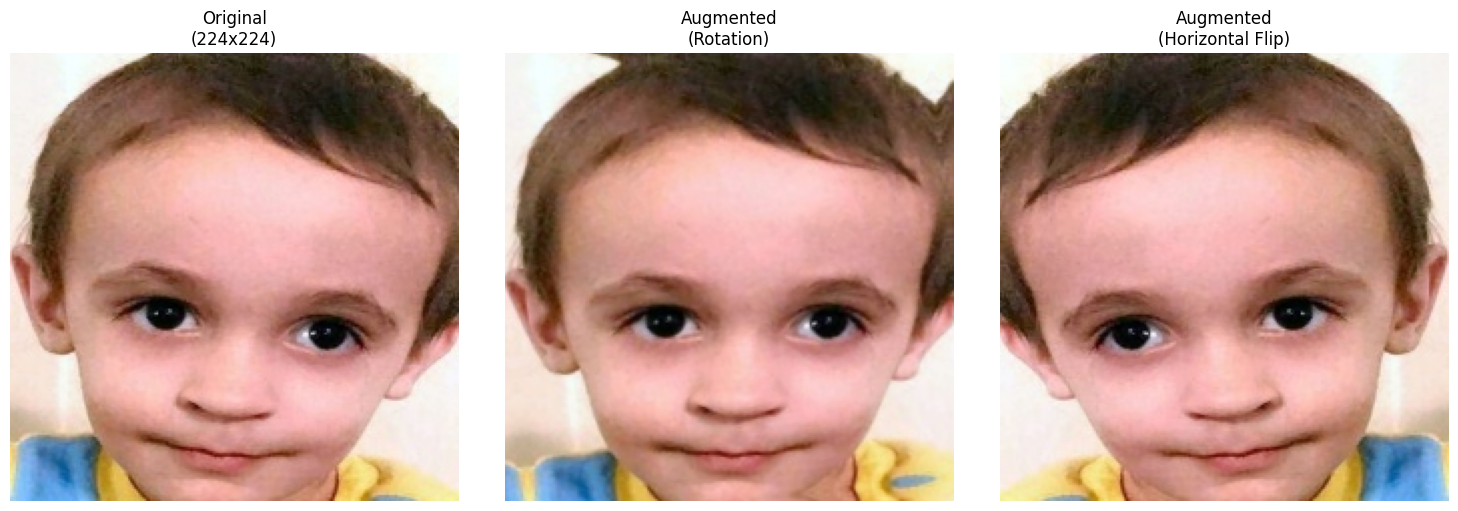

In [18]:
def visualisasi_preprocessing_aug(image_path):
    # 1. Load Original Image
    img_orig = cv2.imread(image_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    orig_shape = img_orig.shape
    
    # 2. Resize (Skenario Percobaan 1 & 3: 224x224)
    target_size = (224, 224)
    img_resized = cv2.resize(img_orig, target_size)
    
    # 3. Augmentasi (Horizontal Flip & Rotation)
    # Kita pake layer preprocessing Keras biar simpel
    data_augmentation_rotation = tf.keras.Sequential([
        # tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05), # Sekitar 72 derajat
    ])

    data_augmentation_flip = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        # tf.keras.layers.RandomRotation(0.2), # Sekitar 72 derajat
    ])
    
    # Tambah dimensi batch buat augmentasi (rotasi)
    img_aug_rotation = data_augmentation_rotation(tf.expand_dims(img_resized, 0))
    img_aug_rotation = tf.cast(img_aug_rotation[0], tf.uint8)

    # Tambah dimensi batch buat augmentasi (horizontal flip)
    img_aug_flip = data_augmentation_flip(tf.expand_dims(img_resized, 0))
    img_aug_flip = tf.cast(img_aug_flip[0], tf.uint8)

    # Plotting
    plt.figure(figsize=(15, 5))
    
    # # Tampilan Original
    # plt.subplot(1, 3, 1)
    # plt.imshow(img_orig)
    # plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    # plt.axis('off')
    
    # Tampilan Resized
    plt.subplot(1, 3, 1)
    plt.imshow(img_orig)
    plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    plt.axis('off')
    
    # Tampilan Augmented
    plt.subplot(1, 3, 2)
    plt.imshow(img_aug_rotation)
    plt.title("Augmented\n(Rotation)")
    plt.axis('off')

    # Tampilan Augmented
    plt.subplot(1, 3, 3)
    plt.imshow(img_aug_flip)
    plt.title("Augmented\n(Horizontal Flip)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_preprocessing_aug("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

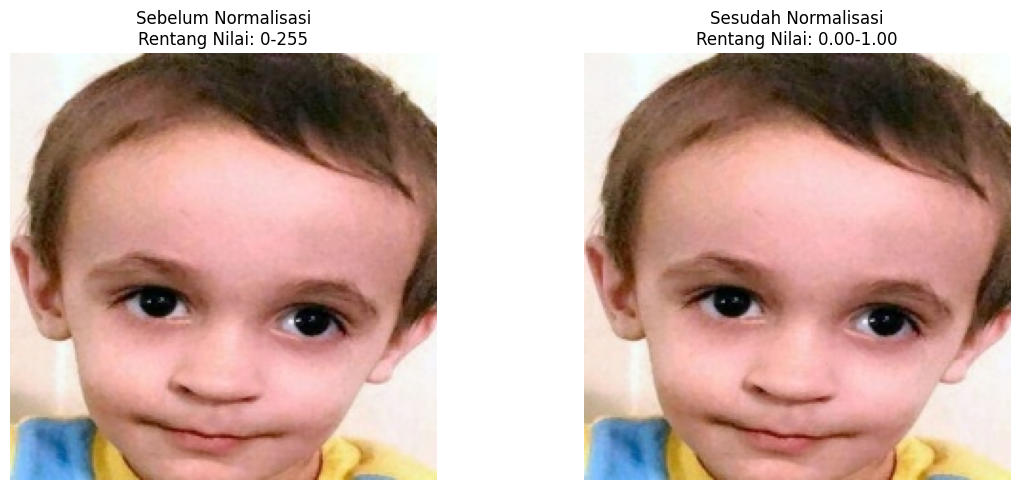

In [19]:
def visualisasi_normalisasi(img_path):
    # 1. Load Original (0-255)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    
    # 2. Normalisasi (Contoh: Scaling ke [0, 1])
    # Di Deep Learning, ini ngebantu konvergensi model lebih cepet
    img_normalized = img_array / 255.0 
    
    # 3. Plotting perbandingan
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Sebelum Normalisasi
    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title(f"Sebelum Normalisasi\nRentang Nilai: {int(np.min(img_array))}-{int(np.max(img_array))}")
    ax[0].axis('off')
    
    # Sesudah Normalisasi
    ax[1].imshow(img_normalized)
    ax[1].set_title(f"Sesudah Normalisasi\nRentang Nilai: {np.min(img_normalized):.2f}-{np.max(img_normalized):.2f}")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_normalisasi("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

In [20]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(1, activation="sigmoid")(combined)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipykernel_6353/1861757166.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_7[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer_7[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  1,704,448 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        513 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,527,745 (105.01 MB)

 Trainable params: 1,704,961 (6.50 MB)

 Non-trainable params: 25,822,784 (98.51 MB)

In [21]:
# === CALLBACKS ===
checkpoint = ModelCheckpoint("asr_s1_aug.keras", monitor="val_accuracy", save_best_only=True)
earlystop = EarlyStopping(monitor="accuracy", patience=10, restore_best_weights=True)

In [22]:
# === TRAIN ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/50


307/307 ━━━━━━━━━━━━━━━━━━━━ 78s 226ms/step - accuracy: 0.7516 - loss: 0.5208 - val_accuracy: 0.7859 - val_loss: 0.4420
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 183ms/step - accuracy: 0.8000 - loss: 0.4228 - val_accuracy: 0.8080 - val_loss: 0.4050
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 55s 179ms/step - accuracy: 0.8185 - loss: 0.3946 - val_accuracy: 0.8276 - val_loss: 0.3741
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 54s 176ms/step - accuracy: 0.8253 - loss: 0.3780 - val_accuracy: 0.8415 - val_loss: 0.3511
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 55s 179ms/step - accuracy: 0.8453 - loss: 0.3433 - val_accuracy: 0.8636 - val_loss: 0.3257
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 55s 179ms/step - accuracy: 0.8587 - loss: 0.3218 - val_accuracy: 0.8570 - val_loss: 0.3246
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 55s 180ms/step - accuracy: 0.8619 - loss: 0.3104 - val_accuracy: 0.8668 - val_loss: 0.3090
Epoch 8/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 53s 173ms/step - accuracy: 0.8713 - loss: 0.2932 - val

In [ ]:
# === EVALUATION ===
loss, acc = model.evaluate(test_gen)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")
# print(f"📉 Model Loss: {loss:.4f}")

error_rate = (1 - acc) * 100
print(f"❌ Error Rate: {error_rate:.2f}%")

39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.9706 - loss: 0.1007

🔥 Model Accuracy: 97.06%
❌ Error Rate: 2.94%


: 

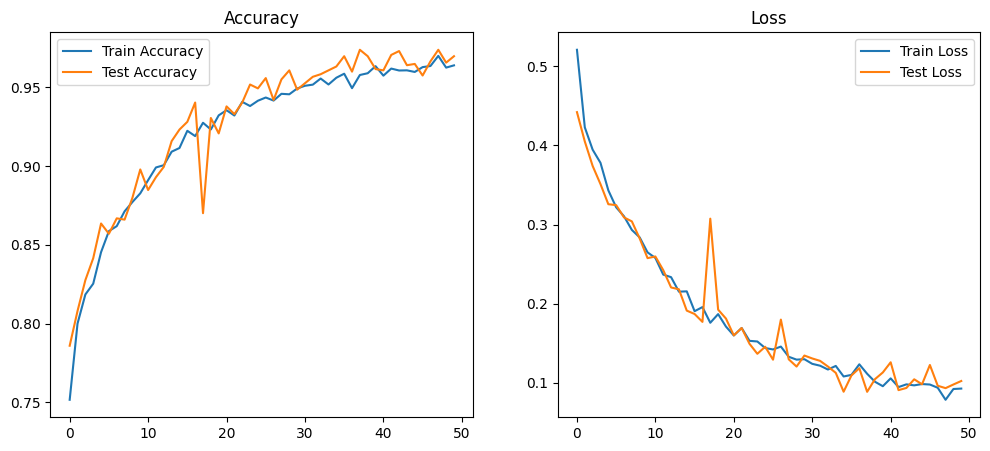

In [24]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 276ms/step
              precision    recall  f1-score   support

    autistic       0.97      0.98      0.98       692
non-autistic       0.98      0.96      0.97       532

    accuracy                           0.97      1224
   macro avg       0.97      0.97      0.97      1224
weighted avg       0.97      0.97      0.97      1224



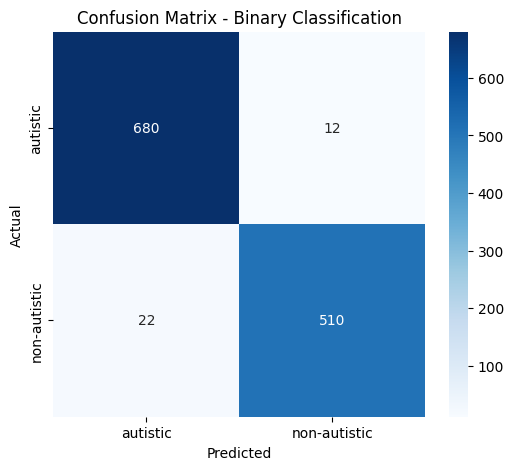

In [25]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen.classes  
class_labels = list(test_gen.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()